# 01 — Filter sensors to the study set

Three transparent rules are applied to every registered sensor and the decision is recorded. The study area is strict Leeds (a bounding box from `config.py`); indoor and test/undeployed units are excluded. Outputs: a full decision log, the clean study list, and a geographic verification map.

**Note on counts:** the filter keeps 48 sensors by these rules. One of them (SL71 Kentmere) has no data folder on disk, so the next notebook combines 47. The 48 → 47 drop is expected, not a bug.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.config import *
import pandas as pd 

df = pd.read_csv(DATA_DIR / "sensor_summary.csv")
print(df.shape)
df.head()

(68, 12)


,sensor_id,sensor_name,pa_id,lat,lon,location_type,last_modified,last_seen,pm25_a,pm25_b,time_stamp_a,time_stamp_b
0,1,SL71 - Kentmere,51535,53.825920,-1.468594,outdoor,2024-09-05 11:37:29,2026-05-10 14:31:10,1,1,2026-05-10 14:31:10,2026-05-10 14:31:10
1,2,SEE(#2) - UPSURGE - Crossley St,117263,53.930550,-1.389377,indoor,2024-05-09 17:29:19,2024-04-28 02:11:15,0,0,2024-04-28 02:11:15,2024-04-28 02:11:15
2,3,SL050 - Bardsey,131651,53.889965,-1.439765,outdoor,2023-10-18 13:47:20,2026-08-20 06:08:27,15,15,2026-08-20 06:08:27,2026-08-20 06:08:27
3,4,SL055 - Temple Newsam,131655,53.785603,-1.455717,outdoor,2023-08-15 16:20:29,2025-02-17 00:40:07,14,17,2025-02-17 00:40:07,2025-02-17 00:40:07
4,5,SL018 East Ardsley A650,132055,53.725370,-1.550685,outdoor,2022-09-26 15:48:26,2026-01-26 09:17:57,33,28,2026-01-26 09:17:57,2026-01-26 09:17:57


### Apply three selection rules

Each sensor is assessed against:

1. **Geographic** — coordinates must fall inside the Leeds bounding box defined in `config.py` (not sensor name matching, which is unreliable)
2. **Indoor** — project scope is outdoor air quality only
3. **Not a genuine field monitor** — test rigs, UPSURGE experiment units, and undeployed spares are excluded

In [2]:
def assess(row):
    """Return a semicolon-joined string of exclusion reasons; empty string = keep."""
    name = str(row["sensor_name"]).lower()
    loc  = str(row["location_type"]).lower()
    lat, lon = row["lat"], row["lon"]
    reasons = []

    inside = (LEEDS_BOX["lat_min"] < lat < LEEDS_BOX["lat_max"]
              and LEEDS_BOX["lon_min"] < lon < LEEDS_BOX["lon_max"])
    if not inside:
        reasons.append("outside Leeds area")

    if loc == "indoor" or "inside" in name:
        reasons.append("indoor")

    if "not deployed" in name:
        reasons.append("not deployed")
    if any(k in name for k in ["upsurge", "data test", "experimental", "highspeed", "unassigned"]):
        reasons.append("test/experimental")

    return "; ".join(reasons)

df["exclude_reason"] = df.apply(assess, axis=1)
df["keep"] = df["exclude_reason"] == ""
print(f"Keep: {df['keep'].sum()}   Exclude: {(~df['keep']).sum()}")

Keep: 48   Exclude: 20


### Excluded sensors — audit trail

In [3]:
excluded = df[~df["keep"]].sort_values("exclude_reason")
display(excluded[["sensor_name", "lat", "lon", "location_type", "exclude_reason"]])

print("\nExclusions by reason combination:")
print(excluded["exclude_reason"].value_counts().to_string())

,sensor_name,lat,lon,location_type,exclude_reason
10,SL047 (OAKLEA),53.890400,-1.438621,indoor,indoor
34,SL058 - SEE Building 10.102,53.825676,-1.587510,indoor,indoor
35,Ibadan Study OUTSIDE (SL052),53.888240,-1.430587,indoor,indoor
11,SL002 - NOT DEPLOYED,53.805830,-1.555835,indoor,indoor; not deployed
54,SL043 - NOT DEPLOYED,53.889942,-1.439613,indoor,indoor; not deployed
1,SEE(#2) - UPSURGE - Crossley St,53.930550,-1.389377,indoor,indoor; test/experimental
21,SL004 - UPSURGE - Crossley St,53.930702,-1.389783,indoor,indoor; test/experimental
36,SL059 - UPSURGE DATA TEST,53.805077,-1.554896,indoor,indoor; test/experimental
38,SL053 - UPSURGE - Crossley St,53.930454,-1.389116,indoor,indoor; test/experimental
41,SL049 - UPSURGE data test,53.826397,-1.588688,indoor,indoor; test/experimental



Exclusions by reason combination:
exclude_reason
indoor; test/experimental     9
indoor                        3
outside Leeds area; indoor    3
indoor; not deployed          2
outside Leeds area            2
not deployed                  1


### Kept study set

In [4]:
kept = df[df["keep"]].sort_values("sensor_name")
print(f"Study set: {len(kept)} Leeds outdoor sensors")
kept[["sensor_name", "location_type", "lat", "lon", "last_seen"]].sort_values("last_seen",ascending=False)

Study set: 48 Leeds outdoor sensors


,sensor_name,location_type,lat,lon,last_seen
67,SL062 Stainburn View,outdoor,53.838860,-1.528167,2026-08-20 06:09:08
58,SL026 Richmond Avenue,outdoor,53.816566,-1.573675,2026-08-20 06:08:46
57,SL025 - Oakwood,outdoor,53.826885,-1.501485,2026-08-20 06:08:40
47,SL037 Lotherton Hall,outdoor,53.819187,-1.319971,2026-08-20 06:08:39
33,SL056 - Infirmary Street/East Parade,outdoor,53.797850,-1.549465,2026-08-20 06:08:28
9,SL042 Manston Grove,outdoor,53.809742,-1.450043,2026-08-20 06:08:27
2,SL050 - Bardsey,outdoor,53.889965,-1.439765,2026-08-20 06:08:27
32,SL051 - Bramham,outdoor,53.868920,-1.318880,2026-08-20 06:08:20
46,SL006 - Primrose Hill Primary,outdoor,53.801888,-1.667109,2026-08-20 06:08:11
12,"SL011 - West End Grove, Horsforth",outdoor,53.838055,-1.655033,2026-08-20 06:07:59


### Save decision log and study list

In [5]:
df[["sensor_id", "sensor_name", "location_type", "lat", "lon",
    "keep", "exclude_reason"]].to_csv(
    Tables / "sensor_filter_decisions.csv", index=False)

kept[["sensor_id", "sensor_name", "location_type", "lat", "lon"]].to_csv(
    Tables / "study_sensors.csv", index=False)

print("Saved:")
print("  outputs/tables/sensor_filter_decisions.csv  (all 68 sensors, with reasons)")
print("  outputs/tables/study_sensors.csv            (the 48 keepers)")

Saved:
  outputs/tables/sensor_filter_decisions.csv  (all 68 sensors, with reasons)
  outputs/tables/study_sensors.csv            (the 48 keepers)


### Map: kept vs excluded

A geographic check that the bounding box did what was intended. The dashed rectangle is the Leeds box from `config.py`; sensors outside it (Nigeria, Borneo, Long Marston) are shown in red.

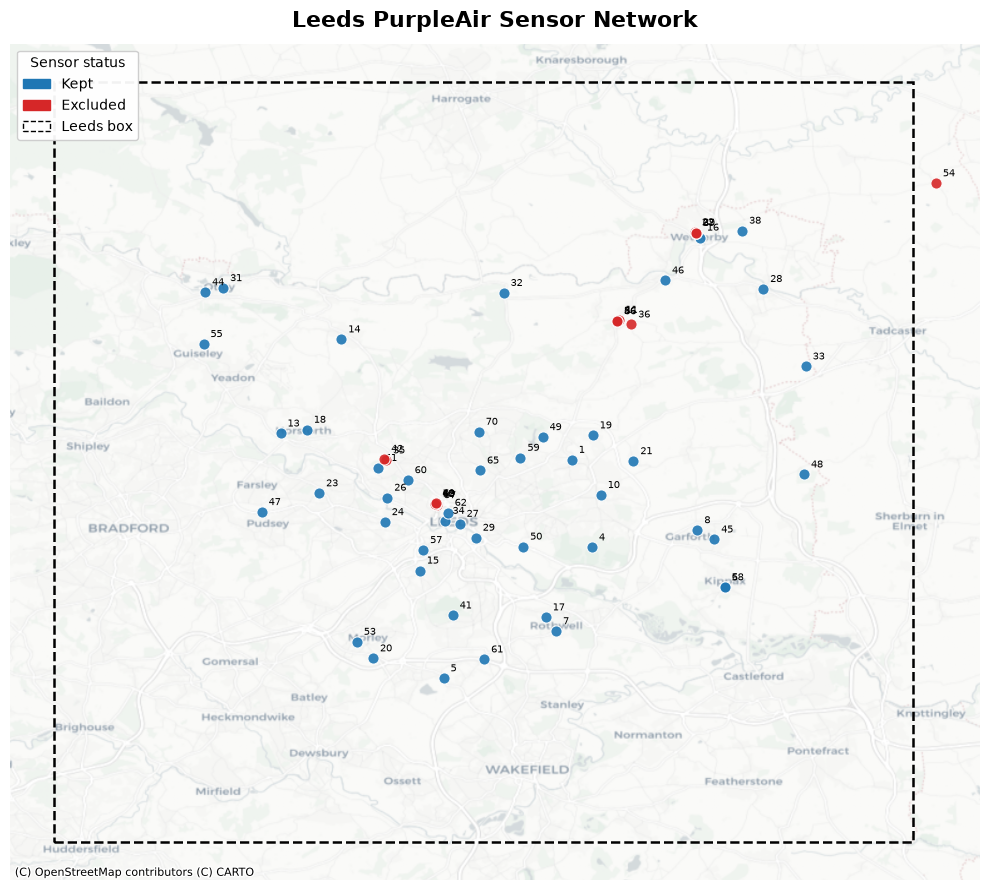

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as cx

# Clip to sensors plausibly near Leeds (removes overseas outliers from the plot)

pad = 0.08
near = df[
    df["lat"].between(LEEDS_BOX["lat_min"] - pad, LEEDS_BOX["lat_max"] + pad) &
    df["lon"].between(LEEDS_BOX["lon_min"] - pad, LEEDS_BOX["lon_max"] + pad)
].copy()

fig, ax = plt.subplots(figsize=(10, 9))

for keep_flag, colour, label in [(True, "tab:blue", "Kept"),
                                  (False, "tab:red", "Excluded")]:
    sub = near[near["keep"] == keep_flag]

    ax.scatter(
        sub["lon"], sub["lat"],
        c=colour,
        s=65,
        label=label,
        edgecolor="white",
        linewidth=0.8,
        alpha=0.9,
        zorder=3
    )

    # Sensor names
    for _, row in sub.iterrows():
        ax.annotate(
            row["sensor_id"],
            (row["lon"], row["lat"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=7
        )

# Leeds bounding box
b = LEEDS_BOX
ax.add_patch(mpatches.Rectangle(
    (b["lon_min"], b["lat_min"]),
    b["lon_max"] - b["lon_min"],
    b["lat_max"] - b["lat_min"],
    fill=False,
    edgecolor="black",
    linestyle="--",
    linewidth=1.8,
    zorder=4
))

# Add Leeds box to legend
leeds_box_patch = mpatches.Patch(
    facecolor="none",
    edgecolor="black",
    linestyle="--",
    label="Leeds box"
)

cx.add_basemap(
    ax,
    crs="EPSG:4326",
    source=cx.providers.CartoDB.Positron
)

ax.set_axis_off()

ax.legend(
    handles=[
        mpatches.Patch(color="tab:blue", label="Kept"),
        mpatches.Patch(color="tab:red", label="Excluded"),
        leeds_box_patch
    ],
    loc="upper left",
    frameon=True,
    framealpha=0.95,
    title="Sensor status"
)

ax.set_title(
    "Leeds PurpleAir Sensor Network",
    fontsize=16,
    fontweight="bold",
    pad=12
)

plt.tight_layout()

plt.savefig(
    Figures / "01_sensor_filter_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()